## Ejercicio 3

El dataset Landscape Image Colorization consta de 7219 imágenes de calles, edificios, montañas, glaciares, y árboles, entre otros. Este contiene dos versiones de cada imagen: una en escala de grises y otra en color, almacenadas en dos carpetas separadas. La versión original de este archivo está disponible en:

https://www.kaggle.com/datasets/theblackmamba31/landscape-image-colorization/data

<div style="text-align: center;">
    <img src='../imagenes/p6-ej3.png' width="60%">
</div>

Desarrolle un modelo de autoencoder que permita generar versiones a color de imágenes en escala de grises. Utilice capas convolucionales tanto en el bloque codificador como decodificador. 

Dado que en la etapa del decodificador requiere capas para aumentar la dimensión para formar la imagen final, implemente 3 versiones diferentes:

**a)** Utilizando capas Upsampling2D.

**b)** Utilizando capas Reescale.

**c)** Utilizando capas Conv2DTranspose.

Luego de entrenados los distintos modelos compare los resultados de las imágenes coloreadas.

In [1]:
FUENTES_DIR = '../FUENTES'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Data_Sets/p6/' # carpeta donde se encuentran los datasets
LOCAL_DIR = DATOS_DIR 

import os
MODELOS_DIR = os.path.abspath(DATOS_DIR+'Modelos/')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# agrega ruta de busqueda donde tenemos archivos .py
import sys
sys.path.append(FUENTES_DIR)

In [3]:
import numpy as np
import re
import matplotlib.pyplot as plt
import os
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import img_to_array
from tqdm import tqdm
from zipfile import ZipFile
from PIL import Image
import glob


#!dir $LOCAL_DIR

## Preparación del Archivo de Datos
#### Copia de Archivo y Descompresión

Recupera el archivo comprimido de la carpeta de g-drive y lo descomprime en una carpeta local para hacer más rápido el acceso a las imágenes. Realiza la descompresión archivo por archivo para visualizar el progreso (útil cuando el archivo es grande).

In [ ]:
ZIP_ARCH = 'landscape_color_gray.zip'  # Archivo comprimido

# Verificar y crear la carpeta de datos local si no existe
if not os.path.exists(LOCAL_DIR):
    os.makedirs(LOCAL_DIR)

# Comprueba la existencia del archivo en la carpeta de destino
zip_path = os.path.join(LOCAL_DIR, ZIP_ARCH)
if not os.path.exists(zip_path):
    source_file = os.path.join(DATOS_DIR, ZIP_ARCH)
    shutil.copy(source_file, LOCAL_DIR)  # Copiar el archivo a la carpeta local

# Descompresión con barra de progreso
with ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.infolist()
    for file in tqdm(files, desc='Extrayendo', unit=' archivo'):
        zip_ref.extract(file, LOCAL_DIR)

print(f"\nEl archivo {ZIP_ARCH} se ha copiado y descomprimido en {LOCAL_DIR}.")

Extrayendo: 100%|██████████| 14258/14258 [00:01<00:00, 7154.74 archivo/s]


El archivo archive.zip se ha copiado y descomprimido en ../Data_Sets/p6/.


#### Preparación del Dataset

En este bloque se realiza la preparación del conjunto de datos para entrenar y validar la red neuronal que colorea imágenes. Se parte de un conjunto de tuplas o pares de imágenes donde, donde la primera está en escala de grises (entrada del modelo) y la segunda corresponde a la versión en color (objetivo del modelo). Los pasos realizados en este proceso de generación de este conjunto de datos son:
* **Carga de imágenes**: Se leen las imágenes desde disco, asegurando que cada imagen en grises tenga su contraparte en color con el mismo nombre de archivo.
* **Preprocesamiento**: Las imágenes son redimensionadas a un tamaño fijo y normalizadas para que sus valores estén entre 0 y 1.
* **Estructuración como dataset TensorFlow**: Los datos se organizan en un objeto ***tf.data.Dataset***, que permite aplicar transformaciones eficientes como:
  * Mezclar aleatoriamente los ejemplos.
  * Aplicar procesamiento en paralelo.
  * Agrupar en lotes para entrenamiento por mini-lotes(minibatches).
  * Prefetch para optimizar el flujo de datos al modelo.
* **División entrenamiento-validación**:
  * **Entrenamiento (75%)**: utilizado por el modelo para aprender los patrones de coloreado.
  * **Validación (25%)**: utilizado para evaluar el rendimiento del modelo durante el entrenamiento y evitar sobreajuste.

In [6]:
# Configuración
TAM_IMG = 96   # Tamaño de la imagen que será procesada por la red
FACTOR_ENTRENA = 0.75  # Proporción del dataset para entrenamiento
TAM_LOTE = 64  # Tamaño de los lotes

ruta_color = 'landscape Images/color/'
ruta_grises = 'landscape Images/gray/'

# Función optimizada para cargar y procesar imágenes
@tf.function # Esto convierte una función python en una versión tensorflow con el objetivo de mejorar el rendimiento
def load_and_process(gray_path, rgb_path, img_size=(TAM_IMG, TAM_IMG)):
    # Carga paralela de ambos archivos
    gray_img = tf.io.read_file(gray_path)
    rgb_img = tf.io.read_file(rgb_path)
    # Decodificación paralela
    gray_img = tf.image.decode_jpeg(gray_img, channels=1)
    rgb_img = tf.image.decode_jpeg(rgb_img, channels=3)
    # Redimensionar
    gray_img = tf.image.resize(gray_img, img_size)
    rgb_img = tf.image.resize(rgb_img, img_size)
    # Normalizar
    gray_img = tf.cast(gray_img, tf.float32) / 255.0
    rgb_img = tf.cast(rgb_img, tf.float32) / 255.0

    return gray_img, rgb_img

# Función optimizada para cargar el dataset
def cargar_dataset(gray_files, rgb_files, batch_size=32, shuffle_buffer=1000):
    # Crear dataset directamente desde las listas de archivos
    dataset = tf.data.Dataset.from_tensor_slices((gray_files, rgb_files))

    # Shuffle antes de mapear para mejor rendimiento
    if shuffle_buffer:
        dataset = dataset.shuffle(shuffle_buffer, reshuffle_each_iteration=False)
    # Mapeo paralelizado y cacheado
    dataset = dataset.map(
        load_and_process,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Batch y prefetch
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

# Cargar listas de archivos una sola vez
gray_files = sorted([
    os.path.join(LOCAL_DIR+ruta_grises, f) for f in os.listdir(LOCAL_DIR+ruta_grises) if f.endswith('.jpg')
])

rgb_files = [
    f.replace('gray', 'color') for f in gray_files
]

# Verificar correspondencia
assert all(os.path.basename(g) == os.path.basename(r) for g, r in zip(gray_files, rgb_files)), \
       "¡Archivos no coincidentes!"

# Dividir dataset en train/val
cant_total = len(gray_files)
cant_entrena = int(FACTOR_ENTRENA * cant_total)

# Crear datasets directamente divididos
train_gray = gray_files[:cant_entrena]
train_rgb = rgb_files[:cant_entrena]

val_gray = gray_files[cant_entrena:]
val_rgb = rgb_files[cant_entrena:]

# Crear datasets finales
dataset_entrena = cargar_dataset(
    train_gray,
    train_rgb,
    batch_size=TAM_LOTE,
    shuffle_buffer=1000
)

dataset_valida = cargar_dataset(
    val_gray,
    val_rgb,
    batch_size=TAM_LOTE,
    shuffle_buffer=0  # No necesitamos shuffle para validación
)

# Opcional: Cachear los datasets si caben en memoria
dataset_entrena = dataset_entrena.cache()
dataset_valida = dataset_valida.cache()

E0000 00:00:1761918647.683869    9522 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1761918647.695225    9522 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Grafico de algunas imagenes

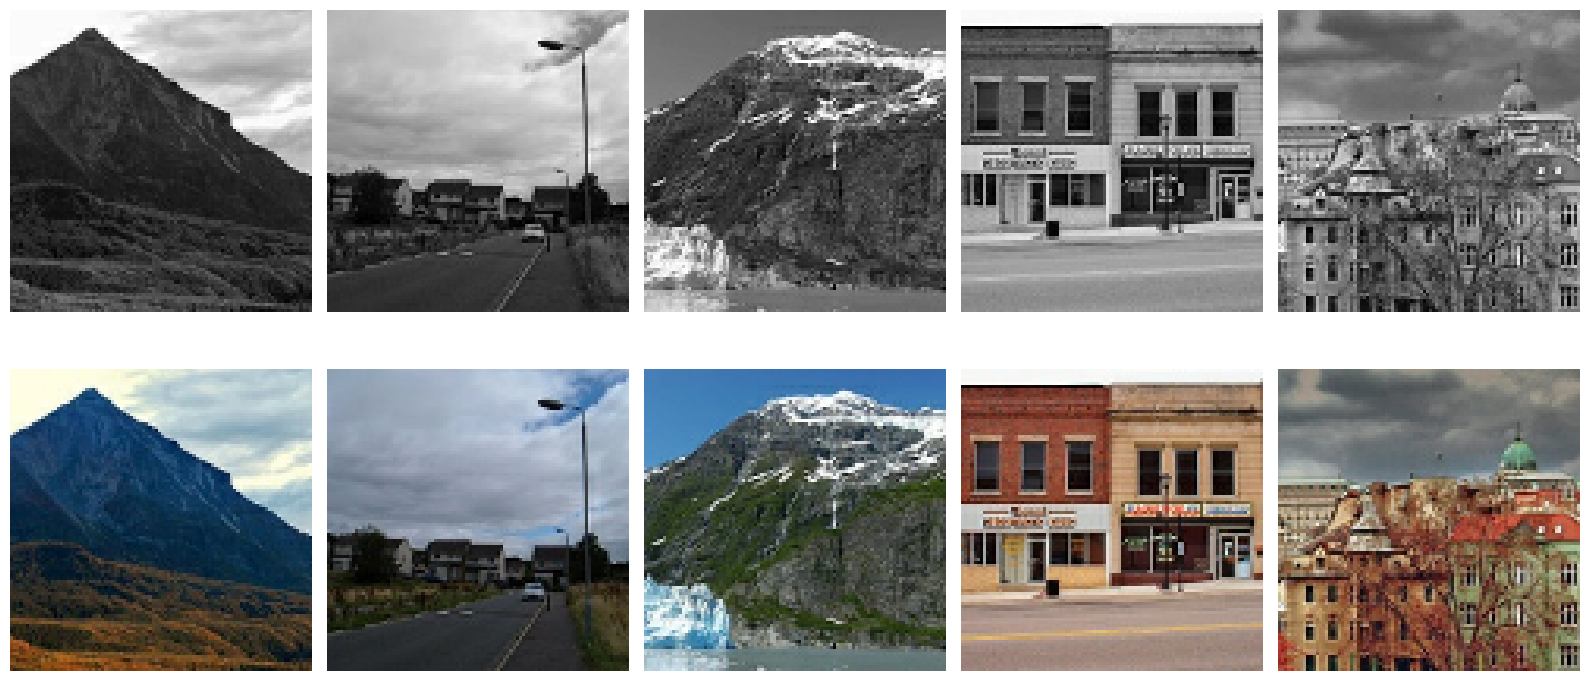

In [7]:
def plot_images_from_tensor(grayscale_images, color_images, num_images=5):
    # Selección directa sin escalar
    color_np = color_images[:num_images].numpy()
    gray_np = grayscale_images[:num_images].numpy().squeeze(-1)

    # Plot
    fig, axes = plt.subplots(2, num_images, figsize=(16, 8))
    if num_images == 1:
        axes = axes.reshape(2, 1)

    for i in range(num_images):
        axes[0, i].imshow(gray_np[i], cmap='gray')  # Grayscale
        axes[1, i].imshow(color_np[i])              # RGB
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Color', fontsize=12)
    axes[1, 0].set_ylabel('Grises', fontsize=12)

    plt.tight_layout()
    plt.show()


# Obtener un batch de tu dataset
lote_imagenes = next(iter(dataset_entrena.take(1)))  # Obtiene el primer batch con tuplas
lote_grises, lote_color = lote_imagenes

plot_images_from_tensor(lote_grises, lote_color, num_images=5)

#### Inciso a)

In [ ]:
from tensorflow.keras import layers, models, optimizers

def crear_modelo_upsampling(img_h, img_w, activ='relu'):
    inputs = layers.Input(shape=(img_h, img_w, 1))

    # --- Encoder ---
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    # --- Bottleneck ---
    x = layers.Conv2D(512, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # --- Decoder con UpSampling2D ---
    x = layers.UpSampling2D(size=(2,2))(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(size=(2,2))(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(size=(2,2))(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Salida RGB
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    return models.Model(inputs, outputs, name='Autoencoder_UpSampling')


#### Inciso b)

In [ ]:
from tensorflow.keras import layers, models

def crear_modelo_rescale(img_h, img_w, activ='relu'):
    inputs = layers.Input(shape=(img_h, img_w, 1))

    # --- Encoder ---
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    # --- Bottleneck ---
    x = layers.Conv2D(512, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # --- Decoder con Reescale ---
    x = layers.Rescaling(2.0)(x)   # Reescala intensidades (no espacial, conceptual)
    x = layers.UpSampling2D(size=(2,2))(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Rescaling(2.0)(x)
    x = layers.UpSampling2D(size=(2,2))(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Rescaling(2.0)(x)
    x = layers.UpSampling2D(size=(2,2))(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    return models.Model(inputs, outputs, name='Autoencoder_Rescale')


#### Inciso c)

# Construccion del modelo

In [8]:
from tensorflow.keras import layers, models, optimizers, activations

def crear_modelo(img_h, img_w, activ='relu'):
    inputs = layers.Input(shape=(img_h, img_w, 1))

    # --- Encoder ---
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    # --- Bottleneck ---
    x = layers.Conv2D(512, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    #x = layers.Conv2D(512, (3,3), activation=activ, padding='same')(x)
    #x = layers.BatchNormalization()(x)

    # --- Decoder ---
    x = layers.Conv2DTranspose(256, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(128, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(64, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Output
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    return models.Model(inputs=inputs, outputs=outputs)

    
# Crear y compilar el modelo
model = crear_modelo(TAM_IMG, TAM_IMG, activ='leaky_relu')
model.compile(optimizer=optimizers.Adam(learning_rate=0.0005),
                       loss='mean_absolute_error')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 24, 24, 256)    │     1,179,904 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 48, 48, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 128)    │       147,58

 Total params: 4,656,899 (17.76 MB)

 Trainable params: 4,653,187 (17.75 MB)

 Non-trainable params: 3,712 (14.50 KB)

# Entrenamiento

In [9]:
es = callbacks.EarlyStopping(
    monitor='val_loss',  # Monitorea la pérdida de validación
    patience=15,         # Número de épocas sin mejora antes de detener
    restore_best_weights=True,  # Restaura los mejores pesos encontrados
)

history = model.fit(
    dataset_entrena,
    validation_data=dataset_valida,
    epochs=500,
    callbacks=[es],
    verbose=1
)

Epoch 1/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 378s 5s/step - loss: 0.1114 - val_loss: 0.2211
Epoch 2/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 367s 4s/step - loss: 0.0889 - val_loss: 0.2165
Epoch 3/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 357s 4s/step - loss: 0.0825 - val_loss: 0.1923
Epoch 4/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 367s 4s/step - loss: 0.0794 - val_loss: 0.1695
Epoch 5/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - loss: 0.0767 - val_loss: 0.1448
Epoch 6/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 374s 5s/step - loss: 0.0753 - val_loss: 0.1100
Epoch 7/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 383s 5s/step - loss: 0.0738 - val_loss: 0.0846
Epoch 8/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 379s 5s/step - loss: 0.0725 - val_loss: 0.0774
Epoch 9/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 375s 5s/step - loss: 0.0713 - val_loss: 0.0858
Epoch 10/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - loss: 0.0703 - val_loss: 0.0890
Epoch 11/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 378s 5s/step - loss: 0.0690 - val_loss: 0.0909
Epoch 12/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step

KeyboardInterrupt: 

# Evaluacion

In [ ]:
model.evaluate(dataset_valida)

import plotly.graph_objects as go

history_dict = history.history
epochs = list(range(1, len(next(iter(history_dict.values()))) + 1))

fig = go.Figure()

for metric_name, values in history_dict.items():
    fig.add_trace(go.Scatter(
        x=epochs,
        y=values,
        mode='lines+markers',
        name=metric_name,
        line=dict(width=2),
        marker=dict(size=4)
    ))

fig.update_layout(
    title='Evolución del Entrenamiento',
    xaxis_title='Época',
    yaxis_title='Valor',
    hovermode='x unified',
    template='plotly_white',
    width=800,
    height=500
)

fig.show()

**Visualización de Resultados**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparasion(dataset_batch, predictions, num_images=5, start_index=0):
    """
    Muestra comparativas entre imágenes originales, escala de grises y predicciones del modelo

    Args:
        dataset_batch: Batch de datos (tupla de tensores (gray_images, color_images))
        predictions: Array de predicciones del modelo (num_images, H, W, 3)
        num_images: Número de imágenes a mostrar
        start_index: Índice inicial dentro del batch
    """
    gray_images = dataset_batch[0][start_index:start_index+num_images].numpy()
    color_images = dataset_batch[1][start_index:start_index+num_images].numpy()

    # Asegurar que las predicciones tienen el mismo número de imágenes
    predictions = predictions[start_index:start_index+num_images]

    fig, axes = plt.subplots(3, num_images, figsize=(16, 10))
    if num_images == 1:
        axes = axes.reshape(3, 1)  # Para manejar correctamente el caso de 1 imagen

    # Mostrar imágenes
    for i in range(num_images):
        # Escala de grises (eliminar dimensión del canal si es necesario)
        axes[0, i].imshow(gray_images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')

        # Original a color
        axes[1, i].imshow(color_images[i])
        axes[1, i].axis('off')

        # Predicción
        axes[2, i].imshow(predictions[i])
        axes[2, i].axis('off')

    # Etiquetas
    axes[0, 0].set_ylabel('Escala de Grises', fontsize=12)
    axes[1, 0].set_ylabel('Original Color', fontsize=12)
    axes[2, 0].set_ylabel('Predicción Modelo', fontsize=12)

    plt.tight_layout()
    plt.show()


ini_imgs = 20
num_imgs = 5

# Obtener un batch del dataset de validación
test_batch = next(iter(dataset_valida.take(1)))
test_gray, test_color = test_batch

# Generar predicciones
predictions = model.predict(test_gray)


plot_comparasion(test_batch, predictions, num_images=num_imgs, start_index=ini_imgs)


In [ ]:
model.save(MODELOS_DIR + 'colorear_rgb_model_c.keras')